<a href="https://colab.research.google.com/github/eliza-aurora-carling/Admin/blob/main/Circadian_disruption_affecting_dopamine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings('ignore')

# Set Times New Roman as default font for all text (with fallbacks)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Liberation Serif', 'serif'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Then paste the PDCircadianModel class definition here (the whole class)
# Then paste the plot_circadian_disruption_pd() function here
# Then call it:



def plot_circadian_disruption_pd():
    """
    Figure 2: How circadian disruption affects PD severity.
    Compares normal rhythm vs disrupted rhythm across disease states.
    All panels share the same y-axis range for direct comparison.
    """
    print("\n" + "=" * 70)
    print("Figure 2: Circadian disruption and PD severity")
    print("=" * 70)

    conditions = [
        ('Healthy', 1.0, '#2E86AB'),
        ('Moderate PD', 0.5, '#8B2252'),
        ('Advanced PD', 0.2, '#CD4F39')
    ]

    circadian_states = [
        ('Normal rhythm', 0.5, 'solid'),
        ('Disrupted rhythm', 0.1, 'dashed')
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    summary = []

    # Find global y-max and y-min for consistent scaling
    all_D_values = []

    # First pass: collect all dopamine values to determine y-limits
    for col, (pd_name, N, base_color) in enumerate(conditions):
        for circ_name, light_amp, linestyle in circadian_states:
            model = PDCircadianModel()
            model.N = N
            model.light_amplitude = light_amp
            solution = model.simulate_steady(days_to_plot=2, sim_days=15)
            D = solution.y[3]
            all_D_values.extend(D)

    y_min = np.min(all_D_values) * 0.95
    y_max = np.max(all_D_values) * 1.05

    # Second pass: plot with consistent y-limits
    for col, (pd_name, N, base_color) in enumerate(conditions):
        ax = axes[col]

        for circ_name, light_amp, linestyle in circadian_states:
            model = PDCircadianModel()
            model.N = N
            model.light_amplitude = light_amp

            # Use same color but different linestyle
            if linestyle == 'dashed':
                color = '#666666'  # Grey for disrupted
            else:
                color = base_color

            solution = model.simulate_steady(days_to_plot=2, sim_days=15)
            t = solution.t
            D = solution.y[3]

            mean_D = np.mean(D)
            peak_D = np.max(D)
            amplitude_D = peak_D - np.min(D)

            summary.append({
                'PD state': pd_name,
                'Circadian': circ_name,
                'Mean D': mean_D,
                'Amplitude': amplitude_D,
                'Peak D': peak_D
            })

            label = f"{circ_name}"
            ax.plot(t % 24, D, color=color, linestyle=linestyle,
                   linewidth=2.5, label=label)

        ax.set_xlabel('Time (hours)', fontfamily='Times New Roman')
        ax.set_ylabel('Dopamine (nM)', fontfamily='Times New Roman')
        ax.set_title(f'{pd_name}\n(N = {N})', fontfamily='Times New Roman')
        ax.set_xlim(0, 24)
        ax.set_ylim(y_min, y_max)  # SHARED Y-AXIS - KEY CHANGE
        ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black', fontsize=9)
        ax.grid(True, alpha=0.3)
        # No grey shading - removed for clarity

    plt.suptitle('Circadian disruption exacerbates dopamine deficiency',
                fontfamily='Times New Roman', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig('figure2_circadian_disruption.png', dpi=300)
    plt.show()

    print("\nSummary of circadian disruption effects:")
    print("-" * 70)
    print(f"{'PD State':<15} {'Rhythm':<15} {'Mean D (nM)':<12} {'Peak D (nM)':<12} {'Amplitude (nM)':<14}")
    print("-" * 70)
    for s in summary:
        print(f"{s['PD state']:<15} {s['Circadian']:<15} {s['Mean D']:<12.3f} {s['Peak D']:<12.3f} {s['Amplitude']:<14.3f}")
    print("-" * 70)

    plot_circadian_disruption_pd()

    return summary


Figure 2: Circadian disruption and PD severity


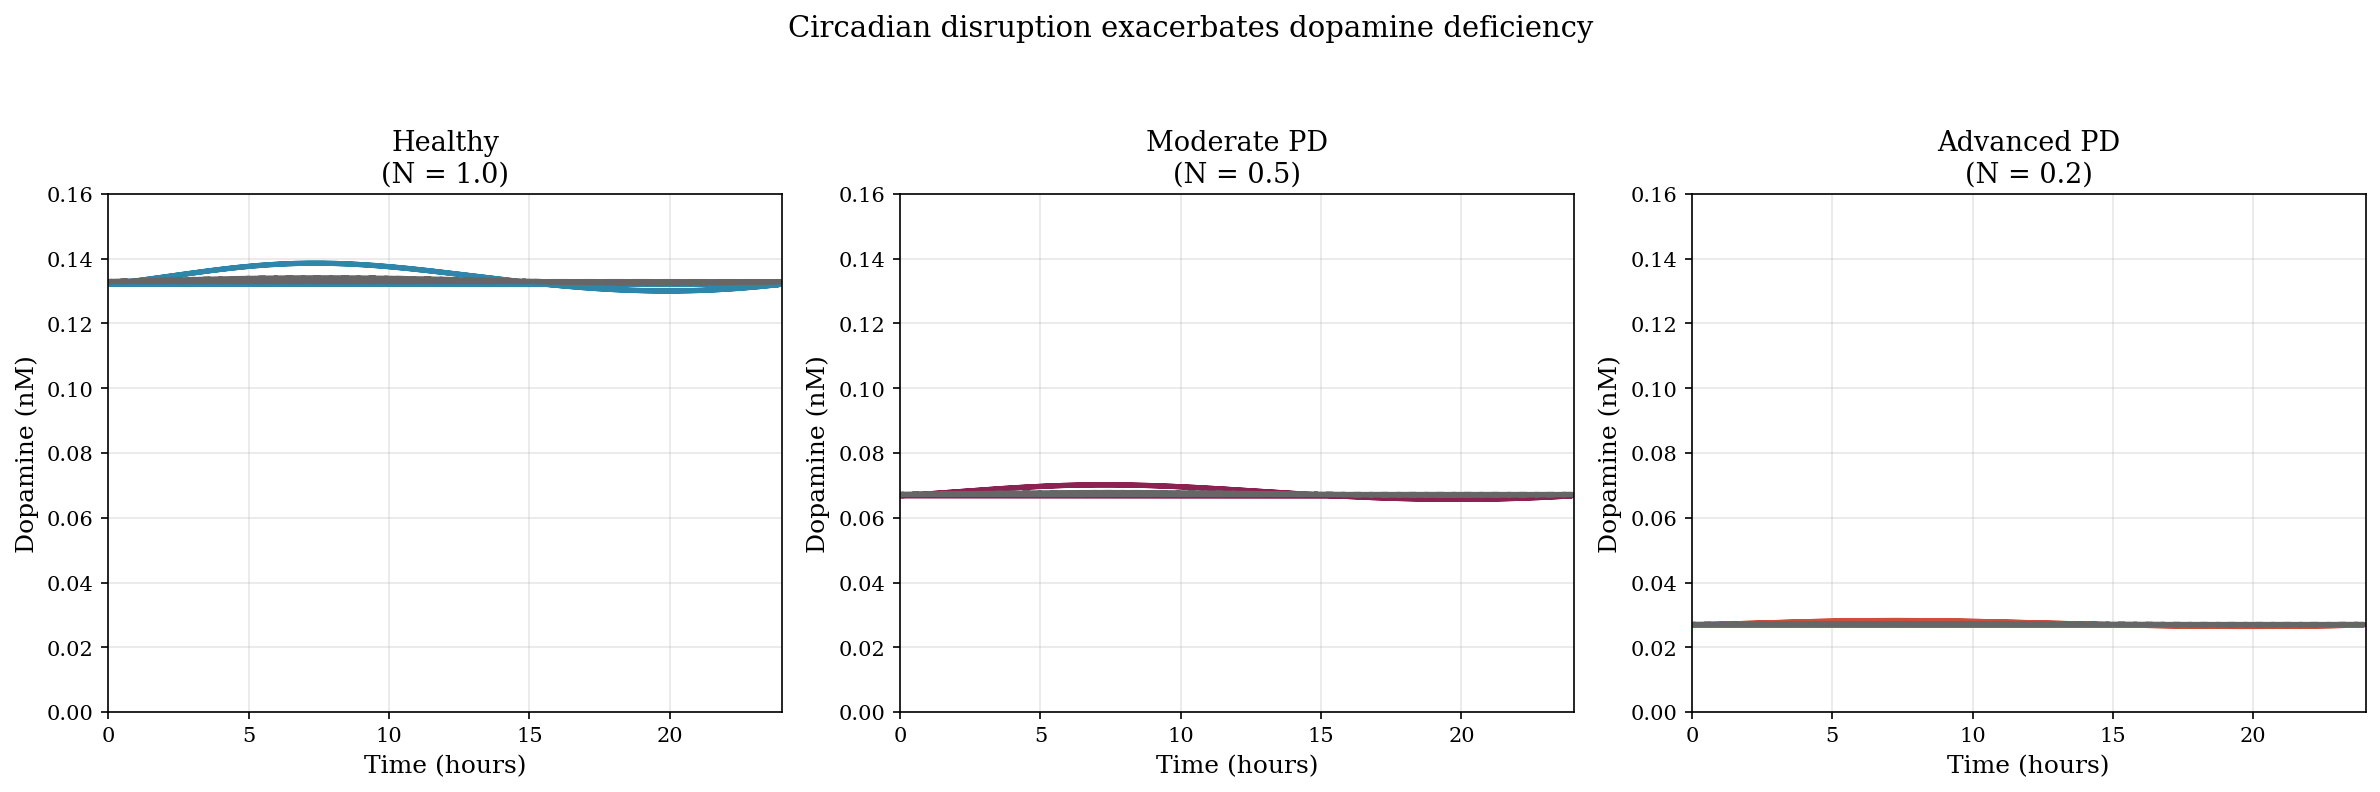


Summary of circadian disruption effects:
----------------------------------------------------------------------
PD State        Rhythm          Mean D (nM)  Peak D (nM)  Amplitude (nM)
----------------------------------------------------------------------
Healthy         Normal rhythm   0.134        0.139        0.009         
Healthy         Disrupted rhythm 0.133        0.134        0.002         
Moderate PD     Normal rhythm   0.068        0.070        0.004         
Moderate PD     Disrupted rhythm 0.067        0.068        0.001         
Advanced PD     Normal rhythm   0.027        0.028        0.002         
Advanced PD     Disrupted rhythm 0.027        0.027        0.000         
----------------------------------------------------------------------


[{'PD state': 'Healthy',
  'Circadian': 'Normal rhythm',
  'Mean D': np.float64(0.13414221083074665),
  'Amplitude': np.float64(0.008582309256830317),
  'Peak D': np.float64(0.13861949832235673)},
 {'PD state': 'Healthy',
  'Circadian': 'Disrupted rhythm',
  'Mean D': np.float64(0.13329426906444566),
  'Amplitude': np.float64(0.0016297611140210777),
  'Peak D': np.float64(0.13411660400724273)},
 {'PD state': 'Moderate PD',
  'Circadian': 'Normal rhythm',
  'Mean D': np.float64(0.067836318695574),
  'Amplitude': np.float64(0.0044828817272609955),
  'Peak D': np.float64(0.07017742746785144)},
 {'PD state': 'Moderate PD',
  'Circadian': 'Disrupted rhythm',
  'Mean D': np.float64(0.06737847876360764),
  'Amplitude': np.float64(0.000848757277722989),
  'Peak D': np.float64(0.067806798851294)},
 {'PD state': 'Advanced PD',
  'Circadian': 'Normal rhythm',
  'Mean D': np.float64(0.02731656051008036),
  'Amplitude': np.float64(0.0018385777823338861),
  'Peak D': np.float64(0.028277290532882006)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings('ignore')

# Set Times New Roman as default font for all text (with fallbacks)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Liberation Serif', 'serif'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})


class PDCircadianModel:
    """
    Coupled circadian-dopamine model for Parkinson's disease.

    State variables:
        C: BMAL1-CLOCK activity (nM)
        R: REV-ERB concentration (nM)
        T: Tyrosine hydroxylase concentration (nM)
        D: Extracellular dopamine concentration (nM)
    """

    def __init__(self):
        # Clock parameters (chosen for stable 24h oscillations)
        self.alpha_C = 1.0       # Max clock production rate (nM/hr)
        self.k_C = 0.5           # Clock half-max repression (nM)
        self.n = 4.0             # Clock Hill coefficient
        self.gamma_C = 0.1       # Clock degradation rate (1/hr)

        # Dopamine feedback to clock
        self.beta_DC = 0.1       # Feedback strength (1/(hr·nM))

        # REV-ERB parameters
        self.beta_R = 1.5        # REV-ERB production rate (1/hr)
        self.gamma_R = 0.5       # REV-ERB degradation rate (1/hr)

        # TH parameters
        self.beta_T = 0.85       # Max TH synthesis rate (nM/hr)
        self.k_T = 1.5           # REV-ERB half-max repression (nM)
        self.m = 1.0             # TH Hill coefficient
        self.gamma_T = 5.6       # TH degradation rate (1/hr)

        # Dopamine parameters
        self.sigma = 0.5         # Dopamine synthesis rate per TH (1/hr)
        self.delta = 0.2         # Dopamine clearance rate (1/hr)

        # Disease parameter
        self.N = 1.0             # Fraction of healthy dopaminergic neurons

        # Circadian disruption parameters
        self.light_amplitude = 0.5  # Normal light entrainment

    def light_input(self, t):
        return 1.0 + self.light_amplitude * np.sin((np.pi / 12) * t - np.pi / 2)

    def system(self, t, y):
        C, R, T, D = np.maximum(y, 0)
        clock_repression = 1.0 / (1.0 + (C / self.k_C) ** self.n)
        light = self.light_input(t)
        dC_dt = (light * self.alpha_C * clock_repression
                 - self.gamma_C * C
                 + self.beta_DC * D)
        dR_dt = self.beta_R * C - self.gamma_R * R
        th_repression = 1.0 / (1.0 + (R / self.k_T) ** self.m)
        dT_dt = (self.beta_T * self.N * th_repression - self.gamma_T * T)
        dD_dt = self.sigma * T - self.delta * D
        return [dC_dt, dR_dt, dT_dt, dD_dt]

    def find_steady_initial_conditions(self, sim_days=10):
        y0 = [0.8, 1.2, 0.4, 1.0]
        t_span = (0, sim_days * 24)
        solution = solve_ivp(
            self.system, t_span, y0, method='RK45',
            t_eval=np.linspace(0, sim_days * 24, sim_days * 100),
            rtol=1e-8, atol=1e-10
        )
        return solution.y[:, -1]

    def simulate_steady(self, days_to_plot=3, sim_days=15):
        y0 = self.find_steady_initial_conditions(sim_days=sim_days)
        t_span = (0, days_to_plot * 24)
        t_eval = np.linspace(0, days_to_plot * 24, days_to_plot * 200)
        solution = solve_ivp(
            self.system, t_span, y0, method='RK45',
            t_eval=t_eval, rtol=1e-8, atol=1e-10
        )
        return solution


def plot_circadian_disruption_pd():
    """
    Figure 2: How circadian disruption affects PD severity.
    Compares normal rhythm vs disrupted rhythm across disease states.
    All panels share the same y-axis range for direct comparison.
    """
    print("\n" + "=" * 70)
    print("Figure 2: Circadian disruption and PD severity")
    print("=" * 70)

    conditions = [
        ('Healthy', 1.0, '#2E86AB'),
        ('Moderate PD', 0.5, '#8B2252'),
        ('Advanced PD', 0.2, '#CD4F39')
    ]

    circadian_states = [
        ('Normal rhythm', 0.5, 'solid'),
        ('Disrupted rhythm', 0.1, 'dashed')
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    summary = []

    # Use fixed y-limits based on your values
    y_min = 0.0
    y_max = 0.16

    for col, (pd_name, N, base_color) in enumerate(conditions):
        ax = axes[col]

        for circ_name, light_amp, linestyle in circadian_states:
            model = PDCircadianModel()
            model.N = N
            model.light_amplitude = light_amp

            if linestyle == 'dashed':
                color = '#666666'
            else:
                color = base_color

            solution = model.simulate_steady(days_to_plot=2, sim_days=15)
            t = solution.t
            D = solution.y[3]

            mean_D = np.mean(D)
            peak_D = np.max(D)
            amplitude_D = peak_D - np.min(D)

            summary.append({
                'PD state': pd_name,
                'Circadian': circ_name,
                'Mean D': mean_D,
                'Amplitude': amplitude_D,
                'Peak D': peak_D
            })

            label = f"{circ_name}"
            ax.plot(t % 24, D, color=color, linestyle=linestyle,
                   linewidth=2.5, label=label)

        ax.set_xlabel('Time (hours)')
        ax.set_ylabel('Dopamine (nM)')
        ax.set_title(f'{pd_name}\n(N = {N})')
        ax.set_xlim(0, 24)
        ax.set_ylim(y_min, y_max)
        # ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black', fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Circadian disruption exacerbates dopamine deficiency',
                fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig('figure2_circadian_disruption.png', dpi=300)
    plt.show()

    print("\nSummary of circadian disruption effects:")
    print("-" * 70)
    print(f"{'PD State':<15} {'Rhythm':<15} {'Mean D (nM)':<12} {'Peak D (nM)':<12} {'Amplitude (nM)':<14}")
    print("-" * 70)
    for s in summary:
        print(f"{s['PD state']:<15} {s['Circadian']:<15} {s['Mean D']:<12.3f} {s['Peak D']:<12.3f} {s['Amplitude']:<14.3f}")
    print("-" * 70)

    return summary


# Call the function
plot_circadian_disruption_pd()